# Healthcare Prescription Analytics using Association Rule Learning

## Project Objective

The aim of this project is to look at prescription transactions and find medicines that tend to appear together.

We will work through the project in this order:

1. Understand the healthcare business problem
2. Import required Python libraries
3. Load and inspect the dataset
4. Identify and handle missing values
5. Standardize medicine names
6. Convert prescription dates into useful time features
7. Perform detailed Exploratory Data Analysis (EDA)
8. Transform prescription records into transaction baskets
9. Encode transactions into binary format
10. Apply the Apriori algorithm
11. Generate association rules
12. Evaluate rules using support, confidence, and lift
13. Interpret the strongest rules from a pharmacy and inventory perspective

> **Important:** Association rules identify statistical co-occurrence patterns. They must not be interpreted as medical treatment recommendations or proof of clinical appropriateness.

## Domain Knowledge

A hospital prescription may contain multiple medicines. In the raw dataset, each medicine appears as a separate row while the same `Prescription_ID` can repeat.

For example:

| Prescription_ID | Medicine_Name |
|---|---|
| RX001 | Paracetamol |
| RX001 | Vitamin C |
| RX001 | Azithromycin |
| RX002 | Metformin |
| RX002 | Telmisartan |

For Association Rule Learning, the repeated rows must be transformed into transaction baskets:

- **RX001** → Paracetamol, Vitamin C, Azithromycin
- **RX002** → Metformin, Telmisartan

This transaction structure allows us to identify medicines that frequently occur together.

## Association Rule Learning

Association Rule Learning is an **unsupervised learning technique** used to discover relationships between items that frequently appear together.

A rule is written as:

**Antecedent → Consequent**

Example:

**Medicine A → Medicine B**

This does not mean Medicine A causes Medicine B to be prescribed. It means that the two medicines occur together frequently enough to form a statistical association.

### Metrics we will use

#### Support
Support measures how frequently an itemset appears in all transactions.

**Support(A) = Number of transactions containing A / Total number of transactions**

A higher support value means the medicine or medicine combination appears frequently.

#### Confidence
Confidence measures how often the consequent appears when the antecedent is already present.

**Confidence(A → B) = Support(A ∪ B) / Support(A)**

A confidence of 0.80 means that 80% of transactions containing A also contain B.

#### Lift
Lift compares the observed association with what would be expected if A and B were independent.

**Lift(A → B) = Confidence(A → B) / Support(B)**

- **Lift > 1:** Positive association
- **Lift = 1:** No meaningful association
- **Lift < 1:** Negative association

Lift is particularly useful because a high-confidence rule can still be uninteresting if the consequent is already extremely common.

## About the Apriori Algorithm

Apriori is a classic frequent-itemset mining algorithm.

It works on the principle:

> If an itemset is frequent, all of its subsets must also be frequent.

### How Apriori works

1. Calculate the support of individual medicines.
2. Remove medicines that do not satisfy minimum support.
3. Generate candidate pairs from frequent medicines.
4. Calculate the support of those pairs.
5. Remove infrequent pairs.
6. Continue generating larger itemsets until no more frequent combinations remain.
7. Convert frequent itemsets into association rules.
8. Evaluate the rules using confidence, lift, and related metrics.

### Limitation

Apriori can become computationally expensive on large datasets because it repeatedly generates candidate itemsets. This is one reason FP-Growth is often used for larger transaction datasets.

## 1. Import Required Libraries

In [1]:
# pandas for working with the dataset
import pandas as pd

# numpy for numerical operations
import numpy as np

# matplotlib for plots
import matplotlib.pyplot as plt

# seaborn for statistical plots
import seaborn as sns

# show all columns while inspecting the data
pd.set_option('display.max_columns', None)

# avoid cutting off longer text values
pd.set_option('display.max_colwidth', 100)


## Observation:

The required libraries were imported for **data analysis, numerical calculations, and visualization**, while the display options were set to show all columns and longer text values clearly.


## 2. Load the Healthcare Prescription Dataset

Keep the CSV file in the same folder as this notebook.

If your file is stored elsewhere, replace the value of `DATA_PATH` with the correct path.

In [2]:
# Define the portable dataset path so the notebook can run on different computers.
DATA_PATH = "/Users/keva/Downloads/healthcare_prescription_analytics_dataset.csv"

# read the healthcare prescription CSV file into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

# display the first five records to verify that the dataset loaded successfully.
df.head()


,Prescription_ID,Patient_ID,Patient_Age,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Quantity,Unit_Price,Total_Medicine_Cost,Prescription_Date,Month,Season,Doctor_ID
0,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Pantoprazole,Antacid/PPI,40mg,13,321.57,4180.41,2025-11-24,Nov,Winter,DOC027
1,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Ondansetron,Antiemetic,250mg,12,139.62,1675.44,2025-11-24,Nov,Winter,DOC027
2,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Calcium,Supplement,5ml,15,38.68,580.20,2026-01-24,Jan,Winter,DOC056
3,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Vitamin D3,Vitamin/Supplement,10mg,9,53.88,484.92,2026-01-24,Jan,Winter,DOC056
4,RX000003,PAT01576,50,Adult,Female,Pune,ENT,Ear Infection,Paracetamol,Analgesic/Antipyretic,500mg,5,179.18,895.90,2026-03-01,Mar,Summer,DOC018


## Observation:
The dataset was successfully loaded into a DataFrame, and the first few records confirm that the data contains patient, prescription, diagnosis, medicine, cost, and date-related information.

## 3. Initial Dataset Inspection

In [3]:
# Quickly display the first five records to understand the dataset structure.
df.head()


,Prescription_ID,Patient_ID,Patient_Age,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Quantity,Unit_Price,Total_Medicine_Cost,Prescription_Date,Month,Season,Doctor_ID
0,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Pantoprazole,Antacid/PPI,40mg,13,321.57,4180.41,2025-11-24,Nov,Winter,DOC027
1,RX000001,PAT01144,47,Adult,Female,Indore,General Medicine,Migraine,Ondansetron,Antiemetic,250mg,12,139.62,1675.44,2025-11-24,Nov,Winter,DOC027
2,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Calcium,Supplement,5ml,15,38.68,580.20,2026-01-24,Jan,Winter,DOC056
3,RX000002,PAT01274,35,Young Adult,Female,Hyderabad,Orthopedics,Fracture Follow-up,Vitamin D3,Vitamin/Supplement,10mg,9,53.88,484.92,2026-01-24,Jan,Winter,DOC056
4,RX000003,PAT01576,50,Adult,Female,Pune,ENT,Ear Infection,Paracetamol,Analgesic/Antipyretic,500mg,5,179.18,895.90,2026-03-01,Mar,Summer,DOC018


## Observation:
The first five records show the structure and type of information available in the dataset, including patient details, diagnosis, department, medicines, cost and prescription date.

In [4]:
# display the final five records to verify the dataset ending and formatting.
df.tail()


,Prescription_ID,Patient_ID,Patient_Age,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Quantity,Unit_Price,Total_Medicine_Cost,Prescription_Date,Month,Season,Doctor_ID
36030,RX011998,PAT03801,7,Child,Male,Delhi,Pediatrics,Pediatric Diarrhea,Zinc Syrup,Pediatric Supplement,5ml,1,191.19,191.19,2025-08-17,Aug,Monsoon,DOC039
36031,RX011999,PAT02427,36,Adult,Male,Bengaluru,ENT,Tonsillitis,Azithromycin,Antibiotic,500mg,14,183.93,2575.02,2025-05-26,May,Summer,DOC049
36032,RX011999,PAT02427,36,Adult,Male,Bengaluru,ENT,Tonsillitis,Paracetamol,Analgesic/Antipyretic,500mg,5,296.67,1483.35,2025-05-26,May,Summer,DOC049
36033,RX012000,PAT02859,20,Young Adult,Male,Pune,ENT,Ear Infection,Probiotic,Gut Health,Capsule,6,91.38,548.28,2026-03-04,Mar,Summer,DOC064
36034,RX012000,PAT02859,20,Young Adult,Male,Pune,ENT,Ear Infection,Amoxicillin Clavulanate,Antibiotic,10mg,10,60.13,601.30,2026-03-04,Mar,Summer,DOC064


## Observation:
The last five records confirm that the dataset contains consistent columns and properly formatted records up to the end of the dataset.

In [5]:
# inspect the number of rows and columns available in the dataset.
df.shape


(36035, 18)

## Observation:
The dataset contains 36,035 rows and 18 columns, giving us a good amount of prescription data for further analysis.

In [6]:
# list every column name to understand the available analytical variables.
df.columns.tolist()


['Prescription_ID',
 'Patient_ID',
 'Patient_Age',
 'Age_Group',
 'Gender',
 'City',
 'Department',
 'Diagnosis',
 'Medicine_Name',
 'Medicine_Category',
 'Dosage',
 'Quantity',
 'Unit_Price',
 'Total_Medicine_Cost',
 'Prescription_Date',
 'Month',
 'Season',
 'Doctor_ID']

## Observation:
The dataset has 18 columns covering patient, prescription, medicine, diagnosis, department, cost, date and doctor-related information.

In [7]:
# inspect data types, non-null counts, and memory usage.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36035 entries, 0 to 36034
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Prescription_ID      36035 non-null  object 
 1   Patient_ID           36035 non-null  object 
 2   Patient_Age          36035 non-null  int64  
 3   Age_Group            36035 non-null  object 
 4   Gender               36035 non-null  object 
 5   City                 36035 non-null  object 
 6   Department           36035 non-null  object 
 7   Diagnosis            35689 non-null  object 
 8   Medicine_Name        36035 non-null  object 
 9   Medicine_Category    36035 non-null  object 
 10  Dosage               36035 non-null  object 
 11  Quantity             36035 non-null  int64  
 12  Unit_Price           36035 non-null  float64
 13  Total_Medicine_Cost  36035 non-null  float64
 14  Prescription_Date    36035 non-null  object 
 15  Month                36035 non-null 

## Observation:
Most columns have 36,035 non-null values, while the Diagnosis column has some missing values. The dataset contains both numerical and categorical columns, which will require different types of analysis.

In [8]:
# Statistically summarize the numerical columns using count, mean, spread, and quartiles.
df.describe()


,Patient_Age,Quantity,Unit_Price,Total_Medicine_Cost
count,36035.000000,36035.000000,36035.000000,36035.000000
mean,37.882226,7.923269,233.616176,1848.247543
std,21.300251,4.316388,124.320632,1505.398833
min,1.000000,1.000000,20.000000,20.120000
25%,22.000000,4.000000,126.270000,637.425000
50%,38.000000,8.000000,232.770000,1399.100000
75%,53.000000,12.000000,341.510000,2733.360000
max,92.000000,15.000000,450.000000,6746.850000


In [9]:
# summarize the categorical columns to inspect unique and dominant values.
df.describe(include='object')


,Prescription_ID,Patient_ID,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Prescription_Date,Month,Season,Doctor_ID
count,36035,36035,36035,36035,36035,36035,35689,36035,36035,36035,36035,36035,36035,36035
unique,12000,4848,6,3,10,9,38,115,33,14,485,12,3,150
top,RX005644,PAT01925,Adult,Male,Nagpur,General Medicine,Common Cold,Pantoprazole,Vitamin/Supplement,500mg,2025-10-12,Jan,Summer,DOC021
freq,6,33,9538,18248,3821,9019,2374,2777,3466,8096,139,4653,13456,316


## Observation:
The numerical summary shows an average patient age of about 38 years, an average quantity of about 8 units, and an average unit price of about ₹234. The values also show a wide range in medicine costs.

### Interpretation

At this stage, check:

- Whether the expected columns are present
- Whether numerical columns have sensible minimum and maximum values
- Whether dates are stored as text
- Whether categorical columns contain inconsistent labels
- Whether null values exist
- Whether the dataset contains repeated prescription IDs, which is expected because one prescription can contain multiple medicines

## 4. Data Quality Checks

In [10]:
# count missing values in every column to identify incomplete information.
missing_values = df.isnull().sum()

# display the missing-value count for each column.
missing_values


Prescription_ID          0
Patient_ID               0
Patient_Age              0
Age_Group                0
Gender                   0
City                     0
Department               0
Diagnosis              346
Medicine_Name            0
Medicine_Category        0
Dosage                   0
Quantity                 0
Unit_Price               0
Total_Medicine_Cost      0
Prescription_Date        0
Month                    0
Season                   0
Doctor_ID                0
dtype: int64

## Observation
The only missing values were found in the Diagnosis column. There were 346 missing records, while the other columns had no missing values.
These values were replaced with "Unknown" so that the records could still be used in the analysis.

In [11]:
# calculate the percentage of missing values in each column.
missing_percentage = (df.isnull().sum() / len(df)) * 100

# display missing-value percentages in descending order.
missing_percentage.sort_values(ascending=False)


Diagnosis              0.960178
Prescription_ID        0.000000
Dosage                 0.000000
Season                 0.000000
Month                  0.000000
Prescription_Date      0.000000
Total_Medicine_Cost    0.000000
Unit_Price             0.000000
Quantity               0.000000
Medicine_Category      0.000000
Patient_ID             0.000000
Medicine_Name          0.000000
Department             0.000000
City                   0.000000
Gender                 0.000000
Age_Group              0.000000
Patient_Age            0.000000
Doctor_ID              0.000000
dtype: float64

## Observation
The Diagnosis column has missing values, while all the other columns have 0% missing values. 
So, only the Diagnosis column needs to be handled before further analysis.

In [12]:
# count exact duplicate rows to identify redundant records.
duplicate_rows = df.duplicated().sum()

# display the total number of exact duplicate rows.
duplicate_rows


np.int64(0)

## Observation:

The output is 0, which means there are no exact duplicate rows in the dataset. So, there is no need to remove any duplicate records.

### Important Note on Duplicates

Do not remove rows simply because `Prescription_ID` repeats.

A repeated `Prescription_ID` is expected because one prescription may contain several different medicines.

Only **fully duplicated rows** should be considered true duplicates.

## 5. Handle Missing Diagnosis Values

In [13]:
# inspect records where the diagnosis value is missing.
df[df['Diagnosis'].isnull()].head(10)


,Prescription_ID,Patient_ID,Patient_Age,Age_Group,Gender,City,Department,Diagnosis,Medicine_Name,Medicine_Category,Dosage,Quantity,Unit_Price,Total_Medicine_Cost,Prescription_Date,Month,Season,Doctor_ID
12,RX000006,PAT04399,33,Young Adult,Female,Hyderabad,Gastroenterology,NaN,Probiotic,Gut Health,Capsule,14,133.26,1865.64,2026-03-17,Mar,Summer,DOC069
13,RX000006,PAT04399,33,Young Adult,Female,Hyderabad,Gastroenterology,NaN,Zinc,Supplement,50mg,11,412.43,4536.73,2026-03-17,Mar,Summer,DOC069
146,RX000052,PAT01675,30,Young Adult,Female,Nagpur,General Medicine,NaN,Vitamin B12,Vitamin/Supplement,Capsule,5,75.55,377.75,2025-01-24,Jan,Winter,DOC078
147,RX000052,PAT01675,30,Young Adult,Female,Nagpur,General Medicine,NaN,Vitamin C,Vitamin/Supplement,500mg,13,366.67,4766.71,2025-01-24,Jan,Winter,DOC078
325,RX000111,PAT00397,1,Child,Male,Mumbai,Dermatology,NaN,Cetirizine,Antihistamine,10mg,14,411.05,5754.70,2025-10-17,Oct,Summer,DOC012
326,RX000111,PAT00397,1,Child,Male,Mumbai,Dermatology,NaN,Calamine Lotion,Dermatology,10mg,7,60.14,420.98,2025-10-17,Oct,Summer,DOC012
327,RX000111,PAT00397,1,Child,Male,Mumbai,Dermatology,NaN,Steroid Cream,Dermatology,Tablet,8,305.74,2445.92,2025-10-17,Oct,Summer,DOC012
330,RX000113,PAT00846,39,Adult,Male,Hyderabad,General Medicine,NaN,Vitamin C,Vitamin/Supplement,500mg,14,111.61,1562.54,2025-02-06,Feb,Winter,DOC081
331,RX000113,PAT00846,39,Adult,Male,Hyderabad,General Medicine,NaN,Cetirizine,Antihistamine,10mg,13,210.23,2732.99,2025-02-06,Feb,Winter,DOC081
332,RX000113,PAT00846,39,Adult,Male,Hyderabad,General Medicine,NaN,Paracetamol,Analgesic/Antipyretic,500mg,15,72.96,1094.40,2025-02-06,Feb,Winter,DOC081


## Observation:

The output shows the records where Diagnosis is missing. We can see that some prescription records do not have a diagnosis, so these missing values need to be handled before doing further analysis.

In [14]:
# replace missing diagnosis values with the meaningful label 'Unknown'.
df['Diagnosis'] = df['Diagnosis'].fillna('Unknown')

# verify that diagnosis values no longer contain null entries.
df['Diagnosis'].isnull().sum()


np.int64(0)

## Observation:

The missing values in the Diagnosis column were replaced with "Unknown". 
The output is 0, which confirms that there are no null values left in the Diagnosis column.

## 6. Standardize Medicine Names

In [15]:
# count medicine-name occurrences to detect spelling inconsistencies.
medicine_name_counts = df['Medicine_Name'].value_counts()

# display all medicine frequencies for inspection.
medicine_name_counts


Medicine_Name
Pantoprazole        2777
Cetirizine          2617
Paracetamol         2326
Probiotic           1958
Cough Syrup         1386
                    ... 
PARACETMOL             1
PANTAPRAZOLE           1
GLIMEPIRIDE            1
BENZOYL PEROXIDE       1
AMLODIPINE             1
Name: count, Length: 115, dtype: int64

## Observation:

The output shows how many times each medicine name appears in the dataset. 
This helps us identify medicines with different spellings or naming variations that may need to be standardized before analysis.


In [16]:
# standardize known medicine spelling variations into consistent names.
df['Medicine_Name'] = df['Medicine_Name'].replace({
    'Paracetmol': 'Paracetamol',
    'Vit C': 'Vitamin C',
    'Azithrocin': 'Azithromycin'
})

# recount medicine names to confirm successful standardization.
df['Medicine_Name'].value_counts()


Medicine_Name
Pantoprazole    2777
Cetirizine      2617
Paracetamol     2392
Probiotic       1958
Cough Syrup     1386
                ... 
AZITHROCIN         1
PARACETMOL         1
PANTAPRAZOLE       1
GLIMEPIRIDE        1
AMLODIPINE         1
Name: count, Length: 112, dtype: int64

## Observation:

The medicine names were standardized by replacing the known spelling variations with the correct names. After standardization, 
Paracetmol : Paracetamol,
Vit C : Vitamin C, and
Azithrocin : Azithromycin. 
This helps avoid treating the same medicine as different medicines during analysis.


## 7. Inspect Important Healthcare Categories

In [17]:
# display all unique medicine categories available in the dataset.
df['Medicine_Category'].unique()


array(['Antacid/PPI', 'Antiemetic', 'Supplement', 'Vitamin/Supplement',
       'Analgesic/Antipyretic', 'Antibiotic', 'ENT', 'Antihistamine',
       'Anti-allergic', 'Respiratory', 'Bronchodilator', 'Gut Health',
       'Topical Analgesic', 'Steroid/Inhaler', 'Diuretic',
       'Antihypertensive', 'Statin', 'Antiplatelet', 'Dermatology',
       'Muscle Relaxant', 'NSAID', 'Antidiabetic', 'Neuropathic Pain',
       'Pediatric Supplement', 'Anti-parasitic', 'Antifungal',
       'Supportive Care', 'Rehydration', 'Antacid', 'Thyroid Medicine',
       'Pediatric', 'Liver Medicine', 'Antispasmodic'], dtype=object)

## Observation:

The output shows all the different medicine categories present in the dataset. This helps us understand the different types of medicines available and later compare which categories are more or less commonly prescribed.


In [18]:
# display all unique diagnoses available after cleaning.
df['Diagnosis'].unique()


array(['Migraine', 'Fracture Follow-up', 'Ear Infection',
       'Allergic Rhinitis', 'Bronchitis', 'Unknown', 'Asthma',
       'Gastritis', 'Heart Failure', 'Sinusitis', 'Common Cold',
       'Hypertension', 'Acne', 'Coronary Artery Disease', 'Muscle Spasm',
       'Eczema', 'Diabetic Neuropathy', 'Type 2 Diabetes',
       'Worm Infection', 'Viral Fever', 'Fungal Infection', 'Back Pain',
       'High Cholesterol', 'Bacterial Infection', 'COPD', 'Diarrhea',
       'Anemia', 'IBS', 'Joint Pain', 'Thyroid Disorder', 'Liver Support',
       'Tonsillitis', 'Pediatric Cold', 'Pediatric Diarrhea',
       'Skin Allergy', 'Acid Reflux', 'Body Pain', 'Pediatric Fever',
       'Respiratory Infection'], dtype=object)

## Observation:

The output shows all the unique diagnoses present in the dataset after cleaning. The missing diagnosis values have been replaced with "Unknown", so they are also included in the list. This gives us a complete view of the different diagnoses in the dataset.


In [19]:
# display all unique hospital departments represented in the dataset.
df['Department'].unique()


array(['General Medicine', 'Orthopedics', 'ENT', 'Pulmonology',
       'Gastroenterology', 'Cardiology', 'Dermatology', 'Endocrinology',
       'Pediatrics'], dtype=object)

## Observation:

The output shows all the unique hospital departments present in the dataset. This helps us understand which departments are included and allows us to compare prescription patterns between different departments.


## 8. Date Preparation and Feature Engineering

In [20]:
# convert the prescription-date column into a proper datetime format.
df['Prescription_Date'] = pd.to_datetime(df['Prescription_Date'])

# extract the calendar year for yearly healthcare trend analysis.
df['Year'] = df['Prescription_Date'].dt.year

# extract the numeric month for chronological grouping.
df['Month_Number'] = df['Prescription_Date'].dt.month

# extract the readable month name for intuitive visualizations.
df['Month_Name'] = df['Prescription_Date'].dt.month_name()

# extract the quarter for quarterly prescription analysis.
df['Quarter'] = df['Prescription_Date'].dt.quarter

# display the newly engineered date features.
df[['Prescription_Date', 'Year', 'Month_Number', 'Month_Name', 'Quarter']].head()


,Prescription_Date,Year,Month_Number,Month_Name,Quarter
0,2025-11-24,2025,11,November,4
1,2025-11-24,2025,11,November,4
2,2026-01-24,2026,1,January,1
3,2026-01-24,2026,1,January,1
4,2026-03-01,2026,3,March,1


### Observation:

The Prescription_Date column was converted into a proper date format. From the date, we created Year, Month Number, Month Name, and Quarter columns. These new columns will make it easier to analyze prescription trends by year, month, and quarter.


# 9. Exploratory Data Analysis (EDA)

EDA helps us understand prescription behavior before building association rules.

The objective is to investigate:

- Most frequently prescribed medicines
- Department workload
- Common diagnoses
- Medicine-category distribution
- Patient-age distribution
- Gender distribution
- Monthly prescription trends
- City-wise prescription volume
- Medicine-cost patterns
- Department and medicine-category relationships

## 9.1 Top 10 Most Prescribed Medicines

In [21]:
# count medicine occurrences and select the ten most frequently prescribed medicines.
top_medicines = df['Medicine_Name'].value_counts().head(10)

# display the top ten medicines and their frequencies.
top_medicines

Medicine_Name
Pantoprazole    2777
Cetirizine      2617
Paracetamol     2392
Probiotic       1958
Cough Syrup     1386
Azithromycin    1357
Vitamin C       1169
Vitamin B12     1089
Vitamin D3      1015
Calcium          995
Name: count, dtype: int64

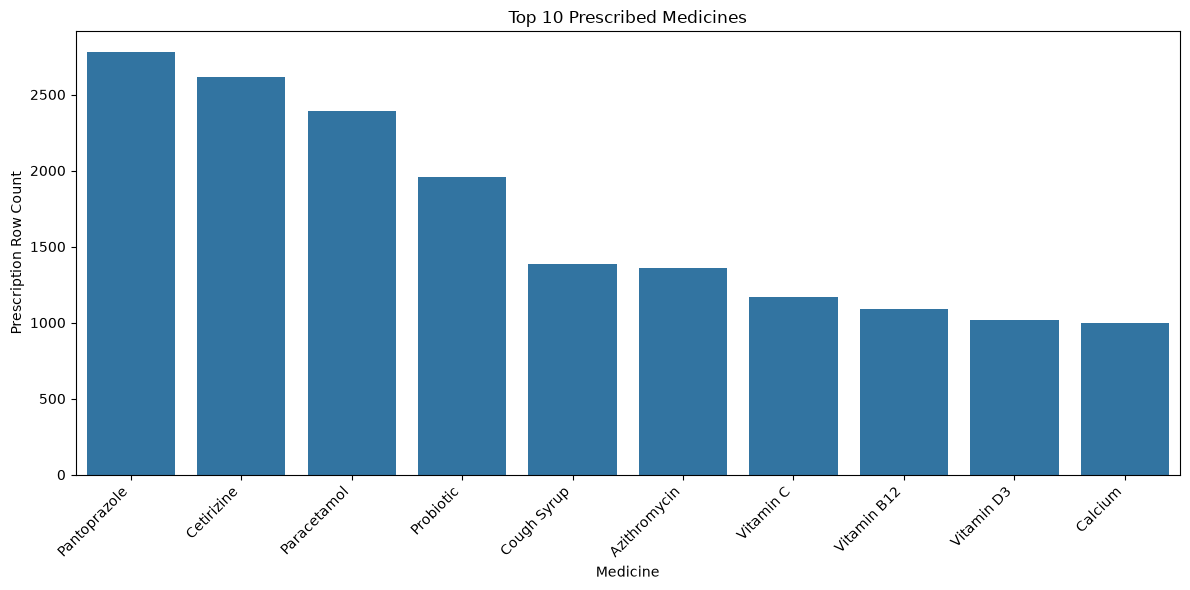

In [22]:
# set the figure size for a readable medicine-frequency chart.
plt.figure(figsize=(12, 6))

# plot the top ten medicines using an informative bar chart.
sns.barplot(x=top_medicines.index, y=top_medicines.values)

# rotate medicine labels to prevent overlapping text.
plt.xticks(rotation=45, ha='right')

# add a title to the visualization.
plt.title("Top 10 Prescribed Medicines")

# label the horizontal axis.
plt.xlabel("Medicine")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

# optimize spacing around chart elements.
plt.tight_layout()

# show the plot
plt.show()


## Observation:

The output shows the 10 most frequently prescribed medicines in the dataset. It helps us quickly identify which medicines are used the most and are likely to have higher demand.
The bar chart makes it easy to compare the top 10 prescribed medicines. We can clearly see which medicines have the highest prescription counts and which ones are prescribed less frequently among the top 10.


### Interpretation

This chart identifies medicines with the highest prescription-row frequency.

From a pharmacy operations perspective, frequently prescribed medicines may require:

- Higher safety stock
- More frequent replenishment
- Closer stock-out monitoring

However, this chart measures individual medicine frequency and does **not** yet tell us which medicines are prescribed together.

## 9.2 Department-wise Prescription Volume

In [23]:
# count prescription rows handled by each department.
department_counts = df['Department'].value_counts()

# display department-level prescription volume.
department_counts


Department
General Medicine    9019
Pulmonology         4436
Cardiology          4015
Endocrinology       3550
ENT                 3508
Pediatrics          3504
Orthopedics         3213
Dermatology         2502
Gastroenterology    2288
Name: count, dtype: int64

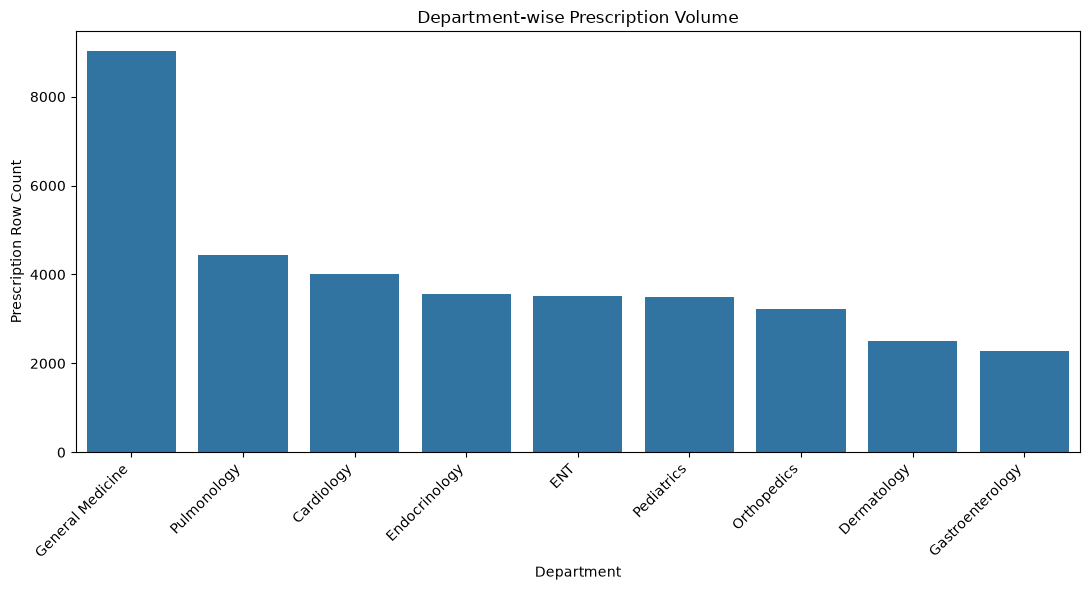

In [24]:
# set the figure size for department-level comparison.
plt.figure(figsize=(11, 6))

# plot departments in descending order of prescription-row frequency.
sns.countplot(data=df, x='Department', order=df['Department'].value_counts().index)

# rotate department labels for improved readability.
plt.xticks(rotation=45, ha='right')

# add a title to the departmental analysis.
plt.title("Department-wise Prescription Volume")

# label the horizontal axis.
plt.xlabel("Department")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:

The code counts the number of prescription records for each department, and the bar plot shows the same comparison visually. General Medicine has the highest prescription volume, while Gastroenterology has the lowest, showing that prescription activity varies across departments.


## 9.3 Diagnosis Frequency

In [25]:
# count the number of prescription rows associated with each diagnosis.
diagnosis_counts = df['Diagnosis'].value_counts()

# display diagnosis frequencies.
diagnosis_counts


Diagnosis
Common Cold                2374
Viral Fever                1522
Type 2 Diabetes            1446
Gastritis                  1428
Bacterial Infection        1385
Sinusitis                  1300
Asthma                     1239
Pediatric Diarrhea         1130
Bronchitis                 1120
Hypertension               1098
Coronary Artery Disease    1087
Joint Pain                 1085
Diabetic Neuropathy        1073
Respiratory Infection      1033
COPD                       1018
Thyroid Disorder           1006
Allergic Rhinitis           970
High Cholesterol            923
Pediatric Cold              895
Pediatric Fever             886
Heart Failure               875
Diarrhea                    805
Migraine                    789
Anemia                      743
Muscle Spasm                715
Fracture Follow-up          711
Body Pain                   679
Back Pain                   673
Eczema                      647
Fungal Infection            625
Acne                        60

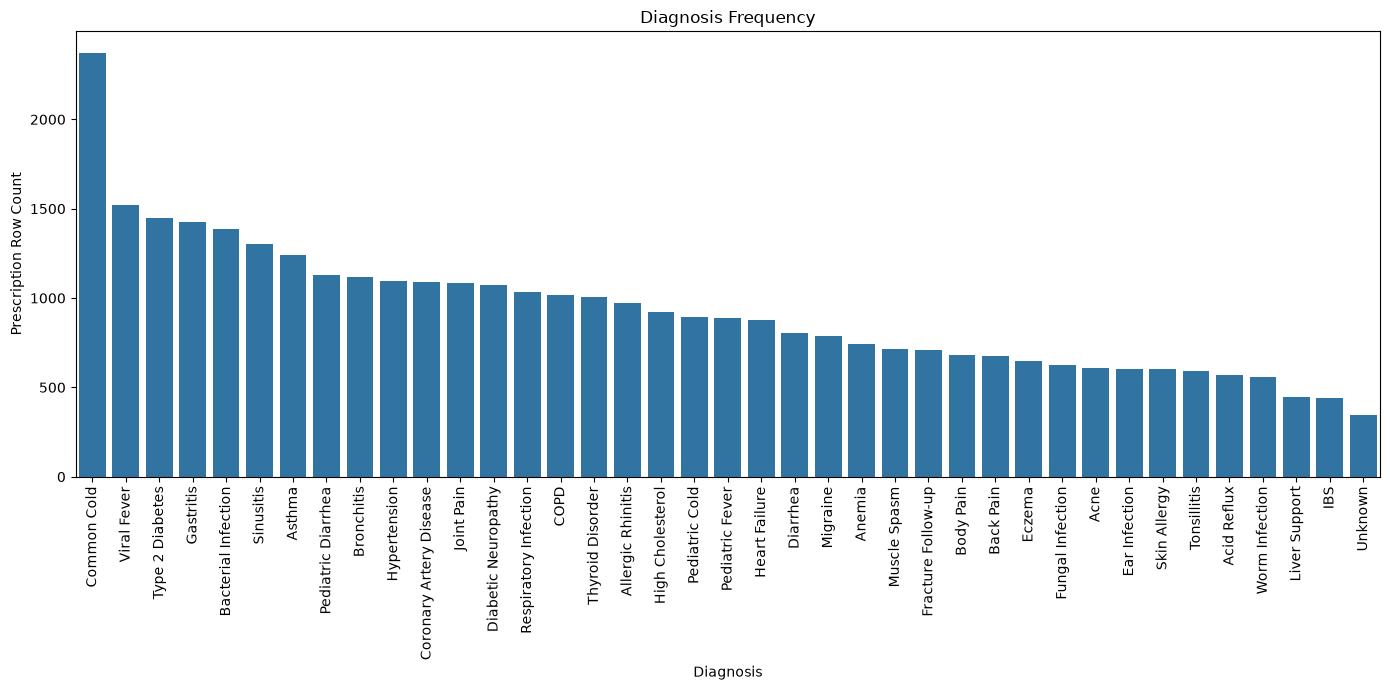

In [26]:
# set the figure size to accommodate multiple diagnosis labels.
plt.figure(figsize=(14, 7))

# compare diagnosis frequencies in descending order.
sns.countplot(data=df, x='Diagnosis', order=df['Diagnosis'].value_counts().index)

# rotate diagnosis labels to make each category readable.
plt.xticks(rotation=90)

# add a title to the diagnosis-frequency visualization.
plt.title("Diagnosis Frequency")

# label the horizontal axis.
plt.xlabel("Diagnosis")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:

The code counts the prescription records for each diagnosis, and the bar plot shows the comparison clearly. Common Cold has the highest number of prescriptions, followed by Viral Fever and Type 2 Diabetes, while some diagnoses have much fewer records. This shows that certain health conditions are more common in the dataset.


### Interpretation

Diagnosis frequency helps explain **why** certain medicine groups may later appear together.

A highly represented diagnosis can produce frequent medicine combinations simply because it occurs often. Therefore, support and lift should be interpreted together when evaluating association rules.

## 9.4 Medicine Category Distribution

In [27]:
# count the number of records belonging to each medicine category.
medicine_category_counts = df['Medicine_Category'].value_counts()

# display medicine-category frequencies.
medicine_category_counts


Medicine_Category
Vitamin/Supplement       3466
Antacid/PPI              2855
Antihistamine            2715
Analgesic/Antipyretic    2418
Supplement               2189
Gut Health               1969
Antibiotic               1780
Respiratory              1401
Dermatology              1272
Antihypertensive         1235
Antidiabetic             1149
Antiplatelet             1088
Bronchodilator           1082
Pediatric Supplement      990
NSAID                     966
Rehydration               928
Pediatric                 920
Antiemetic                919
Statin                    889
Anti-allergic             869
Antacid                   641
ENT                       637
Steroid/Inhaler           563
Diuretic                  548
Muscle Relaxant           450
Neuropathic Pain          362
Supportive Care           329
Thyroid Medicine          327
Anti-parasitic            294
Topical Analgesic         254
Antifungal                217
Liver Medicine            160
Antispasmodic         

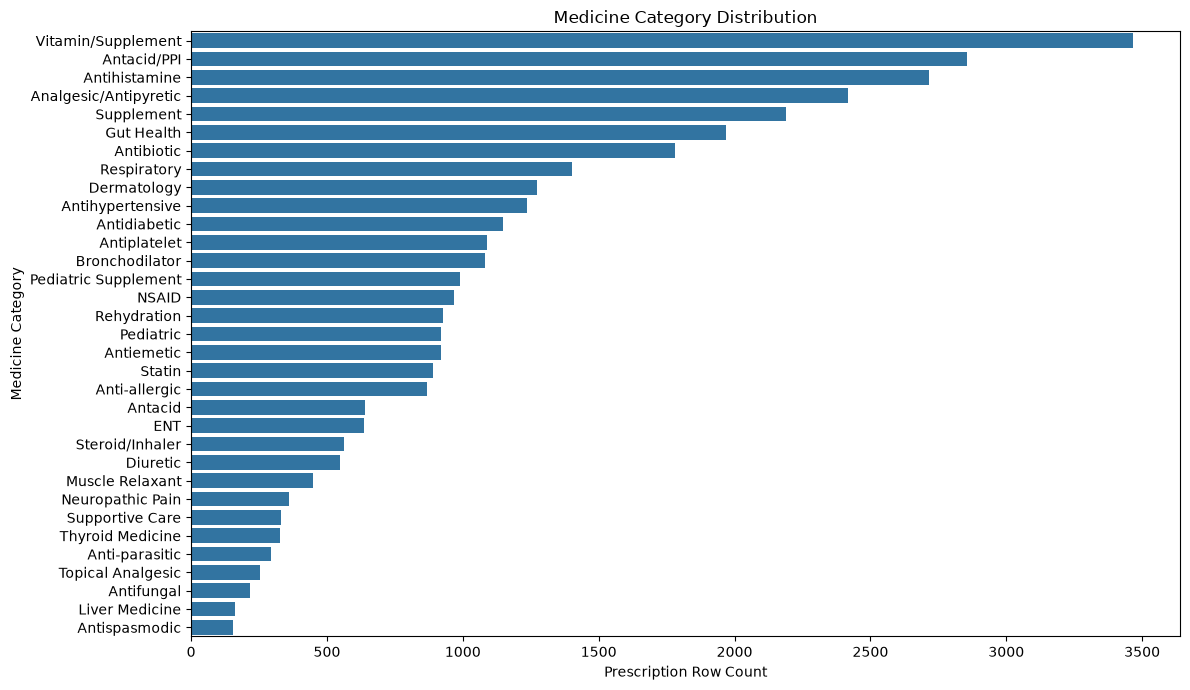

In [28]:
# set the figure size for categorical medicine analysis.
plt.figure(figsize=(12, 7))

# display medicine-category frequencies using a readable horizontal bar chart.
sns.barplot(x=medicine_category_counts.values, y=medicine_category_counts.index)

# add a title to the medicine-category analysis.
plt.title("Medicine Category Distribution")

# label the horizontal axis.
plt.xlabel("Prescription Row Count")

# label the vertical axis.
plt.ylabel("Medicine Category")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:
The chart shows the distribution of different medicine categories. Vitamin/Supplement and Analgesic/Antipyretic categories are among the more commonly prescribed groups, while some categories have fewer prescriptions. This shows that medicine usage varies across categories.

## 9.5 Patient Age Distribution

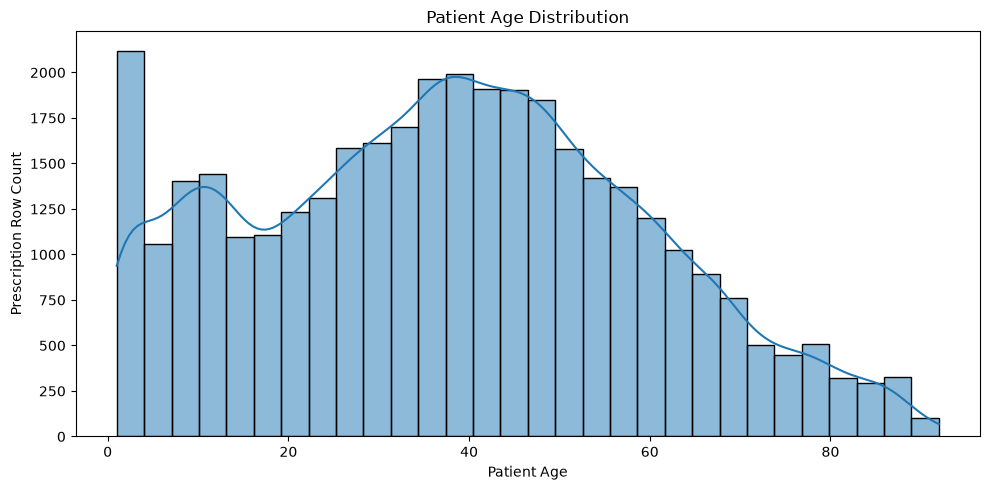

In [29]:
# set the figure size for examining patient-age distribution.
plt.figure(figsize=(10, 5))

# plot patient ages using a detailed histogram with a smooth density curve.
sns.histplot(data=df, x='Patient_Age', bins=30, kde=True)

# add a title to the patient-age analysis.
plt.title("Patient Age Distribution")

# label the horizontal axis.
plt.xlabel("Patient Age")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:
The age distribution shows that the dataset includes patients from children to elderly groups, with the average patient age being around 38 years. This indicates that prescriptions are recorded across a wide range of age groups.

## 9.6 Gender Distribution

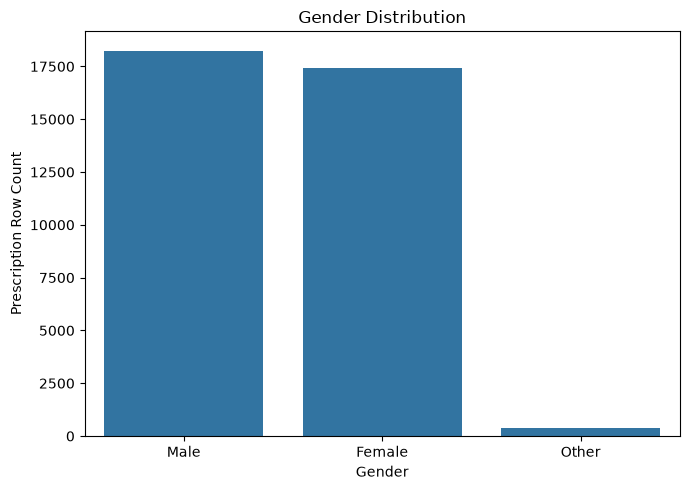

In [30]:
# set the figure size for gender-distribution analysis.
plt.figure(figsize=(7, 5))

# compare prescription-row counts across gender categories.
sns.countplot(data=df, x='Gender', order=df['Gender'].value_counts().index)

# add a title to the gender-distribution chart.
plt.title("Gender Distribution")

# label the horizontal axis.
plt.xlabel("Gender")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:

The code counts prescriptions for each gender and the bar chart shows the comparison. Male patients have the highest number of prescription records, followed by females, while the third gender category has very few records.

## 9.7 Monthly Prescription Trend

In [31]:
# Define the correct chronological order of calendar months.
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# count prescription rows for each month name.
monthly_counts = df['Month_Name'].value_counts().reindex(month_order, fill_value=0)

# display the chronologically ordered monthly counts.
monthly_counts


Month_Name
January      4653
February     4095
March        4627
April        4286
May          2207
June         2190
July         2406
August       2325
September    2245
October      2336
November     2298
December     2367
Name: count, dtype: int64

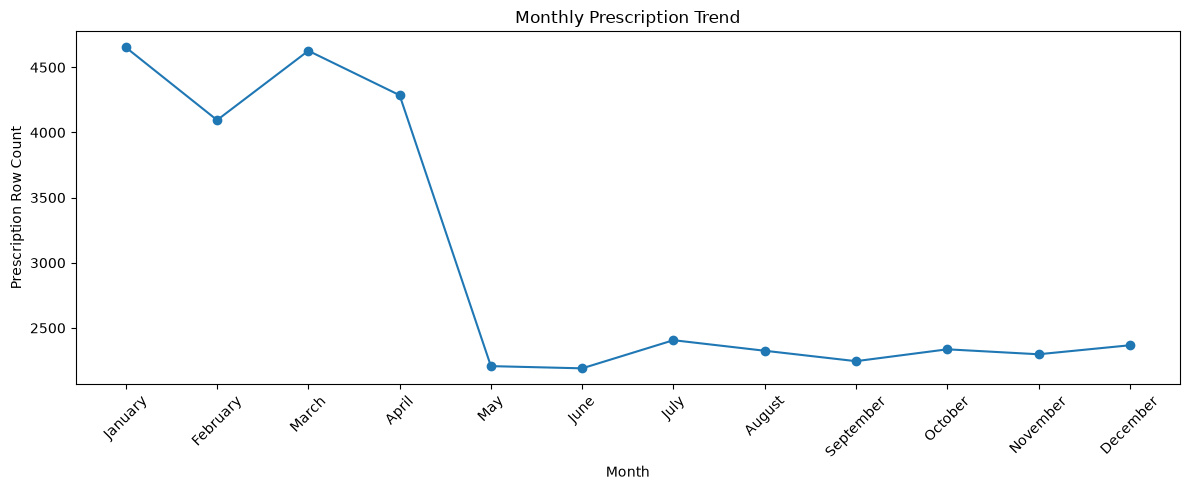

In [32]:
# set the figure size for the monthly prescription trend.
plt.figure(figsize=(12, 5))

# plot month-wise prescription-row counts using a clear line chart.
plt.plot(monthly_counts.index, monthly_counts.values, marker='o')

# add a title to the monthly trend analysis.
plt.title("Monthly Prescription Trend")

# label the horizontal axis.
plt.xlabel("Month")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

# rotate month labels for comfortable reading.
plt.xticks(rotation=45)

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:

The code arranges the months in the correct order and counts prescriptions for each month. The trend shows that January has the highest prescription count (4,653), followed by March, while June has the lowest count (2,190).

## 9.8 Top Cities by Prescription Volume

In [33]:
# identify the ten cities with the highest prescription-row counts.
city_counts = df['City'].value_counts().head(10)

# display the leading cities and their prescription volumes.
city_counts


City
Nagpur       3821
Hyderabad    3663
Mumbai       3650
Delhi        3602
Pune         3586
Bengaluru    3576
Jaipur       3575
Ahmedabad    3541
Indore       3523
Nashik       3498
Name: count, dtype: int64

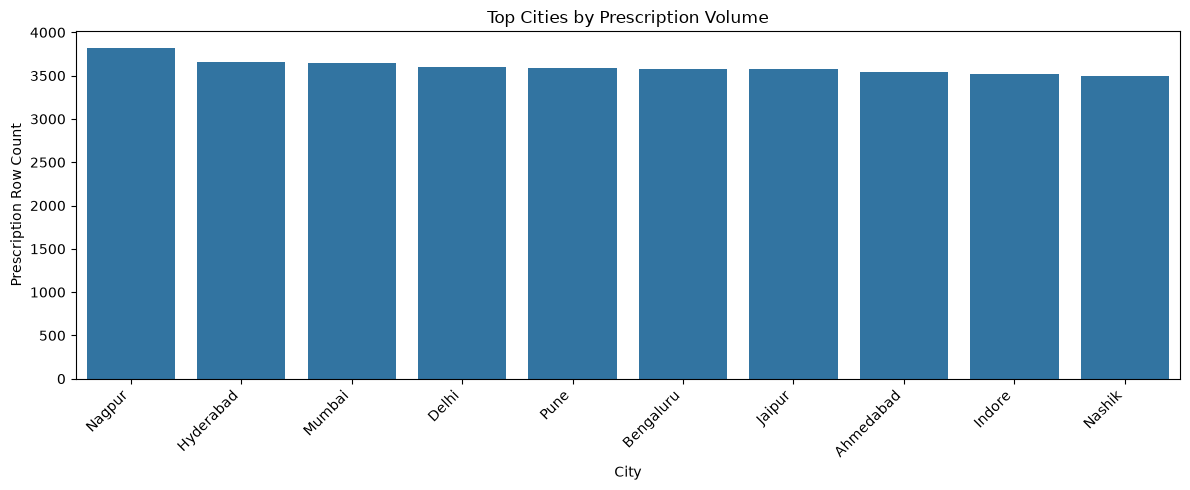

In [34]:
# set the figure size for city-level comparison.
plt.figure(figsize=(12, 5))

# plot the ten cities with the highest prescription-row volumes.
sns.barplot(x=city_counts.index, y=city_counts.values)

# rotate city labels for improved readability.
plt.xticks(rotation=45, ha='right')

# add a title to the city-volume analysis.
plt.title("Top Cities by Prescription Volume")

# label the horizontal axis.
plt.xlabel("City")

# label the vertical axis.
plt.ylabel("Prescription Row Count")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:
The code counts prescriptions for each city and the bar chart compares the top cities. Nagpur has the highest prescription volume with 3,821 records, followed by Hyderabad and Mumbai.

## 9.9 Medicine Cost Analysis

In [35]:
# calculate the average unit price across all medicine records.
average_unit_price = df['Unit_Price'].mean()

# display the average unit price rounded to two decimal places.
round(average_unit_price, 2)


np.float64(233.62)

In [36]:
# calculate the average unit price for each standardized medicine.
average_price_by_medicine = df.groupby('Medicine_Name')['Unit_Price'].mean()

# sort medicines from the highest to the lowest average unit price.
most_expensive_medicines = average_price_by_medicine.sort_values(ascending=False).head(10)

# display the ten medicines with the highest average unit prices.
most_expensive_medicines


Medicine_Name
VITAMIN B COMPLEX       348.390000
FUROSEMIDE              327.476667
PARACETAMOL SYRUP       309.536667
CLOPIDOGREL             299.555000
URSODEOXYCHOLIC ACID    289.020000
PAIN RELIEF GEL         284.160000
MUSCLE RELAXANT         282.655000
CALCIUM                 279.025000
AZITHROMYCIN            277.503750
NASAL SPRAY             271.602222
Name: Unit_Price, dtype: float64

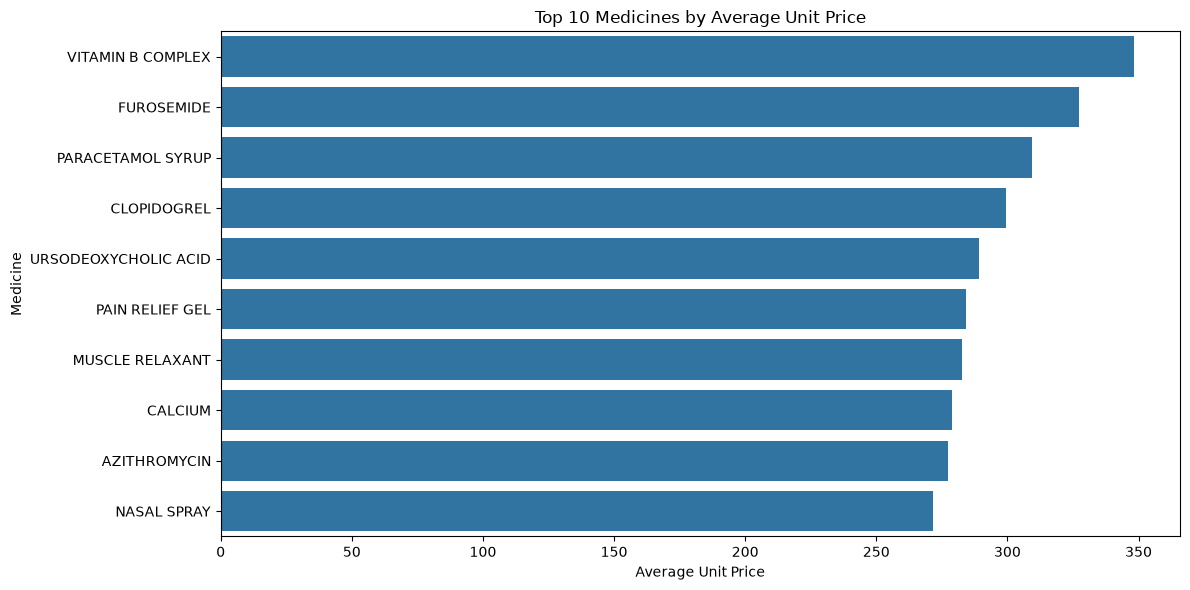

In [37]:
# set the figure size for medicine-cost comparison.
plt.figure(figsize=(12, 6))

# compare the ten medicines with the highest average unit prices.
sns.barplot(x=most_expensive_medicines.values, y=most_expensive_medicines.index)

# add a title to the medicine-cost visualization.
plt.title("Top 10 Medicines by Average Unit Price")

# label the horizontal axis.
plt.xlabel("Average Unit Price")

# label the vertical axis.
plt.ylabel("Medicine")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:
The code calculates the average price of one unit of medicine. This gives us an overall idea of the typical medicine price in the dataset.The code calculates the average price for each medicine and selects the 10 most expensive ones. Vitamin B Complex has the highest average unit price, followed by Furosemide and Paracetamol Syrup.The bar chart makes it easy to compare the average prices of the top 10 medicines. Vitamin B Complex stands out as the most expensive among these medicines, while the remaining medicines have comparatively lower average prices.

## 9.10 Department vs Medicine Category

In [38]:
# create a cross-tabulation between departments and medicine categories.
department_category_table = pd.crosstab(df['Department'], df['Medicine_Category'])

# display the department-by-category frequency matrix.
department_category_table


Medicine_Category,Analgesic/Antipyretic,Antacid,Antacid/PPI,Anti-allergic,Anti-parasitic,Antibiotic,Antidiabetic,Antiemetic,Antifungal,Antihistamine,Antihypertensive,Antiplatelet,Antispasmodic,Bronchodilator,Dermatology,Diuretic,ENT,Gut Health,Liver Medicine,Muscle Relaxant,NSAID,Neuropathic Pain,Pediatric,Pediatric Supplement,Rehydration,Respiratory,Statin,Steroid/Inhaler,Supplement,Supportive Care,Thyroid Medicine,Topical Analgesic,Vitamin/Supplement
Department,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cardiology,1,2,312,2,3,7,25,5,2,0,788,1054,3,3,9,525,4,3,1,3,2,3,3,6,1,5,797,4,339,1,2,5,95
Dermatology,5,0,15,2,3,197,10,4,200,583,7,3,0,2,1180,1,1,191,2,2,5,0,2,3,3,2,16,3,21,2,1,1,35
ENT,379,1,23,310,7,712,11,3,1,618,9,1,3,4,8,2,618,387,2,0,1,3,6,7,2,0,12,4,23,312,2,0,37
Endocrinology,3,2,17,1,1,4,1053,3,0,2,361,5,1,6,9,2,4,3,1,3,4,345,2,5,5,1,7,2,337,1,314,4,1042
Gastroenterology,1,181,462,3,1,1,8,183,1,1,14,5,137,3,7,1,1,397,145,2,2,0,2,2,260,1,6,0,275,0,2,3,181
General Medicine,1769,447,1271,6,3,343,20,710,8,950,23,8,6,9,28,5,2,331,3,6,236,6,8,22,4,580,28,3,665,8,2,4,1505
Orthopedics,1,1,730,2,2,6,10,1,3,2,9,6,1,3,8,3,1,0,3,433,711,2,5,4,4,1,16,1,494,2,0,233,515
Pediatrics,2,4,1,2,272,4,4,6,2,1,6,4,2,5,14,5,1,379,2,0,3,1,889,935,648,289,2,1,6,2,4,3,5
Pulmonology,257,3,24,541,2,506,8,4,0,558,18,2,0,1047,9,4,5,278,1,1,2,2,3,6,1,522,5,545,29,1,0,1,51


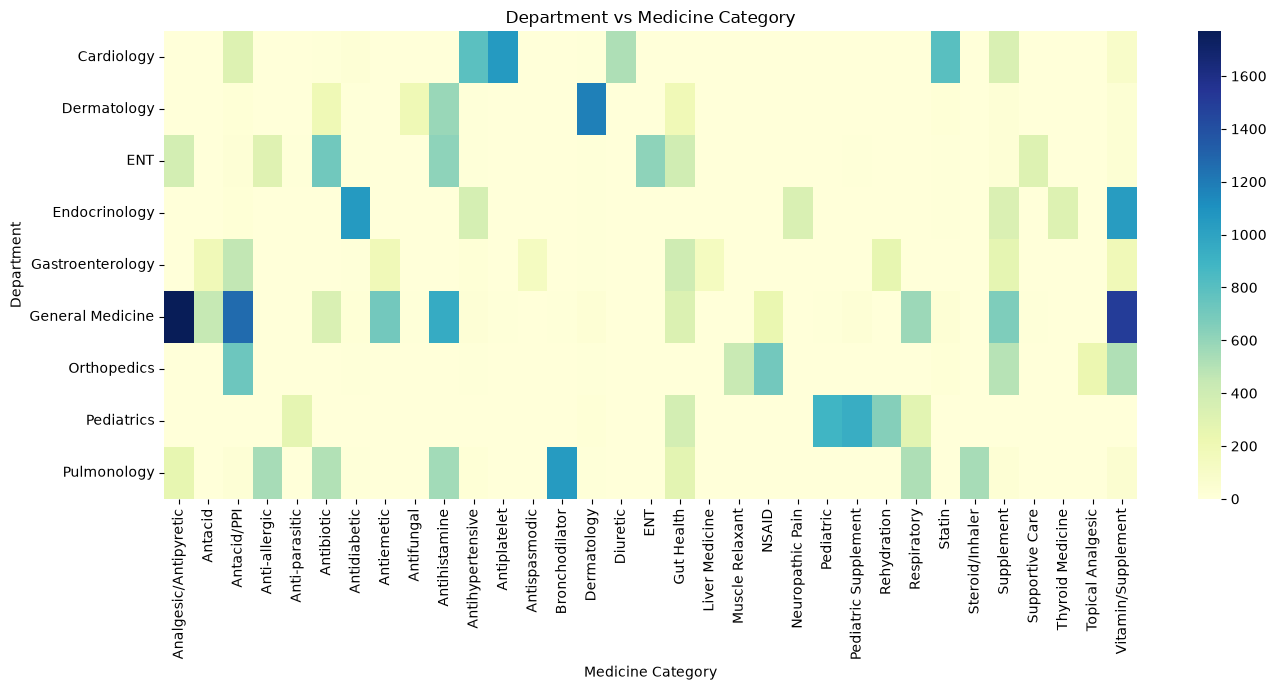

In [39]:
# set the figure size for the department-category relationship.
plt.figure(figsize=(14, 7))

# display category usage across departments using an annotated heatmap.
sns.heatmap(department_category_table, cmap='YlGnBu')

# add a title to the department-category heatmap.
plt.title("Department vs Medicine Category")

# label the horizontal axis.
plt.xlabel("Medicine Category")

# label the vertical axis.
plt.ylabel("Department")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:
The code creates a table showing how different medicine categories are distributed across departments. The heatmap makes the differences easy to see. For example, Pulmonology has high usage of Bronchodilators, while Endocrinology has high usage of Antidiabetic medicines.

# 10. Prepare Transactions for Association Rule Learning

Apriori cannot directly use the original row-level DataFrame.

We first need to transform prescription rows into **medicine baskets** where each prescription represents one transaction.

The transformation occurs in three stages:

1. Group medicine names by `Prescription_ID`
2. Create a prescription × medicine matrix
3. Convert counts into Boolean presence/absence values

## 10.1 Create Prescription Transactions

In [40]:
# group medicine names by prescription so each prescription becomes one transaction.
transactions = df.groupby('Prescription_ID')['Medicine_Name'].apply(list)

# display the first five medicine transactions.
transactions.head()


Prescription_ID
RX000001               [Pantoprazole, Ondansetron]
RX000002                     [Calcium, Vitamin D3]
RX000003    [Paracetamol, Amoxicillin Clavulanate]
RX000004    [Nasal Spray, Cetirizine, Montelukast]
RX000005      [Cough Syrup, Salbutamol, Probiotic]
Name: Medicine_Name, dtype: object

## Observation:
The code groups medicines by Prescription ID, so all medicines belonging to the same prescription are kept together as one basket. For example, one prescription can contain Pantoprazole and Ondansetron together.

### Interpretation

Each row now represents one prescription basket.

Example:

`RX000001 → [Pantoprazole, Ondansetron, ...]`

This is much closer to the structure required for Association Rule Learning.

## 10.2 Build the Medicine Basket Matrix

In [41]:
# count each medicine within every prescription-level transaction.
basket = df.groupby(['Prescription_ID', 'Medicine_Name'])['Medicine_Name'].count().unstack(fill_value=0)

# display the first five rows of the transaction basket.
basket.head()


Medicine_Name,ALBENDAZOLE,AMLODIPINE,AMOXICILLIN CLAVULANATE,ANTACID GEL,ANTIFUNGAL CREAM,ASPIRIN,ATORVASTATIN,AZITHROCIN,AZITHROMYCIN,Albendazole,Amlodipine,Amlodpine,Amoxicillin Clavulanate,Antacid Gel,Antifungal Cream,Aspirin,Atorvastatin,Azithromycin,BENZOYL PEROXIDE,BUDESONIDE,Benzoyl Peroxide,Budesonide,CALCIUM,CETIRIZINE,CETIRIZINE SYRUP,CETRIZINE,CLOPIDOGREL,COUGH SYRUP,Calamine Lotion,Calcium,Cetirizine,Cetirizine Syrup,Cetrizine,Clopidogrel,Cough Syrup,DICLOFENAC,DOMPERIDONE,Diclofenac,Domperidone,Doxycycline,FUROSEMIDE,Fluconazole,Furosemide,GLIMEPIRIDE,Glimepiride,IBUPROFEN,IRON FOLIC ACID,Ibuprofen,Iron Folic Acid,LEVOTHYROXINE,Levothyroxine,METFORMIN,MOISTURIZER,MONTELUKAST,MUSCLE RELAXANT,Mebeverine,Metformin,Metformn,Moisturizer,Montelukast,Muscle Relaxant,NASAL SPRAY,Nasal Spray,OMEGA 3,ONDANSETRON,ORS,Omega 3,Ondansetron,PAIN RELIEF GEL,PANTAPRAZOLE,PANTOPRAZOLE,PARACETAMOL,PARACETAMOL SYRUP,PARACETMOL,PREGABALIN,PROBIOTIC,Pain Relief Gel,Pantaprazole,Pantoprazole,Paracetamol,Paracetamol Syrup,Pregabalin,Probiotic,SALBUTAMOL,SPIRONOLACTONE,STEAM INHALATION,Salbutamol,Spironolactone,Steam Inhalation,Steroid Cream,TELMISARTAN,TIOTROPIUM,Telmisartan,Tiotropium,URSODEOXYCHOLIC ACID,Ursodeoxycholic Acid,VITAMIN B COMPLEX,VITAMIN B12,VITAMIN C,VITAMIN C SYRUP,VITAMIN D3,VITAMIN SYRUP,Vitamin B Complex,Vitamin B12,Vitamin C,Vitamin C Syrup,Vitamin D3,Vitamin Syrup,ZINC,ZINC SYRUP,Zinc,Zinc Syrup
Prescription_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RX000001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
RX000002,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
RX000003,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
RX000004,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
RX000005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In the basket matrix:

- Rows = Prescription IDs
- Columns = Medicines
- Values = Number of times a medicine appears in that prescription

Apriori only needs to know whether a medicine is present, so the next step converts the counts into Boolean values.

In [42]:
# convert medicine counts into Boolean presence values required by modern mlxtend.
basket = basket.astype(bool)

# display the Boolean basket matrix for verification.
basket.head()


Medicine_Name,ALBENDAZOLE,AMLODIPINE,AMOXICILLIN CLAVULANATE,ANTACID GEL,ANTIFUNGAL CREAM,ASPIRIN,ATORVASTATIN,AZITHROCIN,AZITHROMYCIN,Albendazole,Amlodipine,Amlodpine,Amoxicillin Clavulanate,Antacid Gel,Antifungal Cream,Aspirin,Atorvastatin,Azithromycin,BENZOYL PEROXIDE,BUDESONIDE,Benzoyl Peroxide,Budesonide,CALCIUM,CETIRIZINE,CETIRIZINE SYRUP,CETRIZINE,CLOPIDOGREL,COUGH SYRUP,Calamine Lotion,Calcium,Cetirizine,Cetirizine Syrup,Cetrizine,Clopidogrel,Cough Syrup,DICLOFENAC,DOMPERIDONE,Diclofenac,Domperidone,Doxycycline,FUROSEMIDE,Fluconazole,Furosemide,GLIMEPIRIDE,Glimepiride,IBUPROFEN,IRON FOLIC ACID,Ibuprofen,Iron Folic Acid,LEVOTHYROXINE,Levothyroxine,METFORMIN,MOISTURIZER,MONTELUKAST,MUSCLE RELAXANT,Mebeverine,Metformin,Metformn,Moisturizer,Montelukast,Muscle Relaxant,NASAL SPRAY,Nasal Spray,OMEGA 3,ONDANSETRON,ORS,Omega 3,Ondansetron,PAIN RELIEF GEL,PANTAPRAZOLE,PANTOPRAZOLE,PARACETAMOL,PARACETAMOL SYRUP,PARACETMOL,PREGABALIN,PROBIOTIC,Pain Relief Gel,Pantaprazole,Pantoprazole,Paracetamol,Paracetamol Syrup,Pregabalin,Probiotic,SALBUTAMOL,SPIRONOLACTONE,STEAM INHALATION,Salbutamol,Spironolactone,Steam Inhalation,Steroid Cream,TELMISARTAN,TIOTROPIUM,Telmisartan,Tiotropium,URSODEOXYCHOLIC ACID,Ursodeoxycholic Acid,VITAMIN B COMPLEX,VITAMIN B12,VITAMIN C,VITAMIN C SYRUP,VITAMIN D3,VITAMIN SYRUP,Vitamin B Complex,Vitamin B12,Vitamin C,Vitamin C Syrup,Vitamin D3,Vitamin Syrup,ZINC,ZINC SYRUP,Zinc,Zinc Syrup
Prescription_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RX000001,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
RX000002,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
RX000003,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
RX000004,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,Fal

In [43]:
# inspect the number of prescription transactions and unique medicine columns.
basket.shape


(12000, 112)

In [44]:
# count how many prescription baskets contain each medicine.
medicine_frequency = basket.sum().sort_values(ascending=False)

# display the ten most frequent medicines at transaction level.
medicine_frequency.head(10)


Medicine_Name
Pantoprazole    2777
Cetirizine      2617
Paracetamol     2392
Probiotic       1958
Cough Syrup     1386
Azithromycin    1357
Vitamin C       1169
Vitamin B12     1089
Vitamin D3      1015
Calcium          995
dtype: int64

### Why Transaction Frequency Can Differ from Earlier EDA

Earlier EDA counted **medicine rows**.

The basket frequency counts the number of **unique prescriptions containing each medicine**.

For Association Rule Learning, transaction-level frequency is the correct measure.

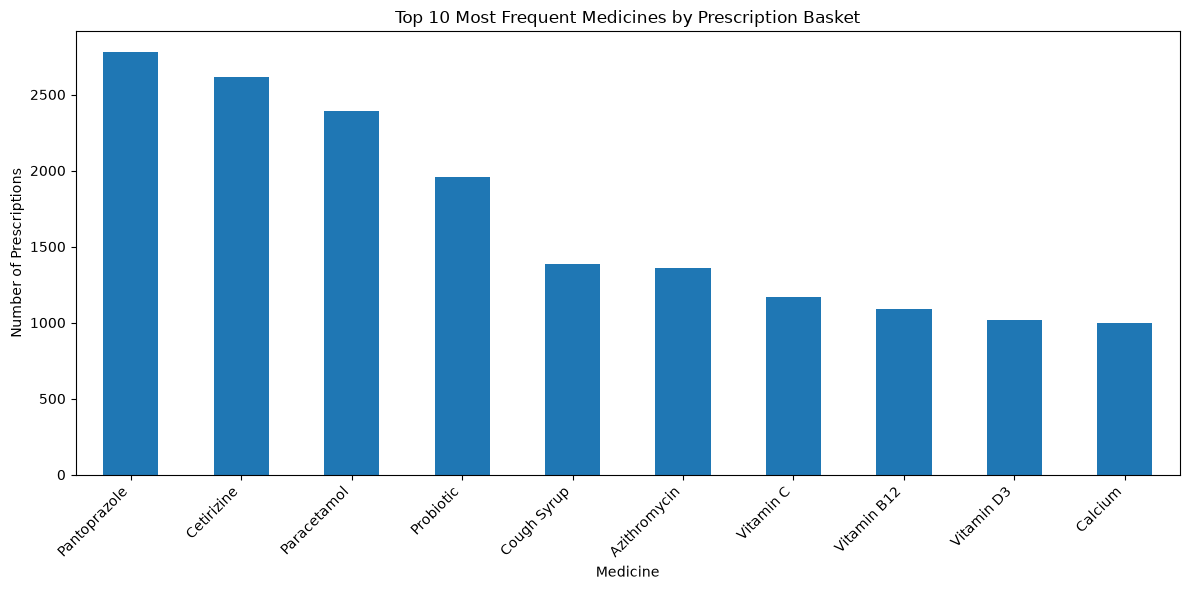

In [45]:
# set the figure size for transaction-level medicine-frequency analysis.
plt.figure(figsize=(12, 6))

# plot the ten medicines appearing in the highest number of prescription baskets.
medicine_frequency.head(10).plot(kind='bar')

# add a title to the transaction-level frequency chart.
plt.title("Top 10 Most Frequent Medicines by Prescription Basket")

# label the horizontal axis.
plt.xlabel("Medicine")

# label the vertical axis.
plt.ylabel("Number of Prescriptions")

# rotate medicine labels for improved readability.
plt.xticks(rotation=45, ha='right')

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:
The prescription data is converted into a **medicine basket matrix**, where each row represents a prescription and each column represents a medicine, with **1 indicating the medicine is present and 0 indicating it is absent**. This prepares the data for Apriori analysis. 


In [ ]:
# 11. Install and Import Apriori Tools

The project uses the `mlxtend` library.
If `mlxtend` is already installed, the installation cell can be skipped.

In [47]:
# install the mlxtend package required for Association Rule Learning.
%pip install -q mlxtend


Note: you may need to restart the kernel to use updated packages.


In [48]:
# Import the classic Apriori function for frequent-itemset discovery.
from mlxtend.frequent_patterns import apriori

# Import the analytical association-rules function for rule generation.
from mlxtend.frequent_patterns import association_rules


# 12. Apply the Apriori Algorithm

We will begin with:

`min_support = 0.02`

This means an itemset must occur in at least **2% of all prescription transactions** to be considered frequent.

The threshold should not be chosen blindly. In a real project, experiment with different support values and evaluate:

- Number of frequent itemsets
- Number of generated rules
- Business usefulness
- Computational cost

In [49]:
# generate frequent medicine itemsets using a meaningful minimum support threshold.
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)

# display the first few frequent medicine itemsets.
frequent_itemsets.head()


,support,itemsets
0,0.024250,(Albendazole)
1,0.022333,(Amlodipine)
2,0.052750,(Antacid Gel)
3,0.067417,(Aspirin)
4,0.073833,(Atorvastatin)


In [50]:
# calculate the number of medicines contained in every frequent itemset.
frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(len)

# sort frequent itemsets from highest to lowest support.
frequent_itemsets_sorted = frequent_itemsets.sort_values(by='support', ascending=False)

# display the strongest frequent itemsets.
frequent_itemsets_sorted.head(20)


,support,itemsets,itemset_length
27,0.231417,(Pantoprazole),1
8,0.218083,(Cetirizine),1
28,0.199333,(Paracetamol),1
31,0.163167,(Probiotic),1
11,0.115500,(Cough Syrup),1
5,0.113083,(Azithromycin),1
39,0.097417,(Vitamin C),1
38,0.090750,(Vitamin B12),1
41,0.084583,(Vitamin D3),1
65,0.083333,"(Cetirizine, Paracetamol)",2


### Interpreting Frequent Itemsets

A frequent itemset such as:

`{Medicine A, Medicine B}`

with support `0.08` means that **8% of all prescription transactions contain both medicines**.

Frequent itemsets are not yet directional rules. They simply identify combinations that occur often enough to satisfy the support threshold.

## Observation:
The Apriori algorithm is applied with a minimum support of 2% to find the medicines or medicine combinations that occur frequently in the prescription transactions.

# 13. Generate Association Rules

In [51]:
# generate directional medicine rules using lift as the initial screening metric.
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

# display the first few generated association rules.
rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Vitamin Syrup),(Albendazole),0.023583,0.024250,0.022083,0.936396,38.614258,1.0,0.021511,15.340958,0.997630,0.857605,0.934815,0.923524
1,(Albendazole),(Vitamin Syrup),0.024250,0.023583,0.022083,0.910653,38.614258,1.0,0.021511,10.928356,0.998312,0.857605,0.908495,0.923524
2,(Domperidone),(Antacid Gel),0.053833,0.052750,0.040500,0.752322,14.262028,1.0,0.037660,3.824522,0.982791,0.612863,0.738529,0.760047
3,(Antacid Gel),(Domperidone),0.052750,0.053833,0.040500,0.767773,14.262028,1.0,0.037660,4.074310,0.981667,0.612863,0.754560,0.760047
4,(Antacid Gel),(Pantoprazole),0.052750,0.231417,0.041083,0.778831,3.365492,1.0,0.028876,3.475095,0.742008,0.169009,0.712238,0.478180


The generated rule table contains several useful metrics, including:

- `antecedents`
- `consequents`
- `antecedent support`
- `consequent support`
- `support`
- `confidence`
- `lift`
- `leverage`
- `conviction`

For this project, the main teaching focus is on **support, confidence, and lift**.

In [52]:
# select the most important columns for readable rule interpretation.
rules_view = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()

# sort rules from the strongest to the weakest lift value.
rules_view = rules_view.sort_values(by='lift', ascending=False)

# display the twenty highest-lift association rules.
rules_view.head(20)


,antecedents,consequents,support,confidence,lift
0,(Vitamin Syrup),(Albendazole),0.022083,0.936396,38.614258
1,(Albendazole),(Vitamin Syrup),0.022083,0.910653,38.614258
185,(Glimepiride),"(Vitamin B12, Telmisartan)",0.021250,0.704420,25.232951
180,"(Vitamin B12, Telmisartan)",(Glimepiride),0.021250,0.761194,25.232951
128,"(Salbutamol, Montelukast)",(Budesonide),0.031583,0.840355,18.104591
129,(Budesonide),"(Salbutamol, Montelukast)",0.031583,0.680431,18.104591
85,(Nasal Spray),(Steam Inhalation),0.021667,0.414013,15.193128
84,(Steam Inhalation),(Nasal Spray),0.021667,0.795107,15.193128
178,(Glimepiride),"(Metformin, Vitamin B12)",0.020000,0.662983,14.491441
175,"(Metformin, Vitamin B12)",(Glimepiride),0.020000,0.437158,14.491441


## Observation:
The strongest association rules show that some medicines are frequently prescribed together. These patterns can help us understand common prescription combinations and may be useful for pharmacy inventory planning.

# 14. Filter Strong Association Rules

In [53]:
# filter rules that show both meaningful confidence and strong positive lift.
strong_rules = rules[(rules['confidence'] >= 0.50) & (rules['lift'] > 1.20)].copy()

# sort the filtered rules from highest to lowest lift.
strong_rules = strong_rules.sort_values(by=['lift', 'confidence'], ascending=False)

# display the key metrics for the strongest filtered rules.
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(30)


,antecedents,consequents,support,confidence,lift
0,(Vitamin Syrup),(Albendazole),0.022083,0.936396,38.614258
1,(Albendazole),(Vitamin Syrup),0.022083,0.910653,38.614258
180,"(Vitamin B12, Telmisartan)",(Glimepiride),0.021250,0.761194,25.232951
185,(Glimepiride),"(Vitamin B12, Telmisartan)",0.021250,0.704420,25.232951
128,"(Salbutamol, Montelukast)",(Budesonide),0.031583,0.840355,18.104591
129,(Budesonide),"(Salbutamol, Montelukast)",0.031583,0.680431,18.104591
84,(Steam Inhalation),(Nasal Spray),0.021667,0.795107,15.193128
178,(Glimepiride),"(Metformin, Vitamin B12)",0.020000,0.662983,14.491441
3,(Antacid Gel),(Domperidone),0.040500,0.767773,14.262028
2,(Domperidone),(Antacid Gel),0.040500,0.752322,14.262028


## How to Interpret a Rule

Suppose a rule is:

**{Medicine A} → {Medicine B}**

with:

- Support = 0.07
- Confidence = 0.65
- Lift = 2.10

Interpretation:

- **Support 0.07:** 7% of all prescription transactions contain both medicines.
- **Confidence 0.65:** 65% of prescriptions containing Medicine A also contain Medicine B.
- **Lift 2.10:** Medicine B occurs with Medicine A about 2.1 times as often as expected under independence.

### Healthcare Caution

This statistical relationship can support:

- Pharmacy inventory planning
- Co-demand analysis
- Stock placement decisions
- Prescription-pattern research

It should **not** be presented as evidence that the medicines should clinically be prescribed together.

# 15. Make Rule Output Easier to Read

In [54]:
# define a helper function that converts frozenset values into readable comma-separated text.
def readable_itemset(itemset):
    # join the sorted item names into one readable string.
    return ', '.join(sorted(list(itemset)))

# copy the filtered rules so the original analytical results remain unchanged.
readable_rules = strong_rules.copy()

# convert antecedent frozensets into readable medicine names.
readable_rules['antecedents'] = readable_rules['antecedents'].apply(readable_itemset)

# convert consequent frozensets into readable medicine names.
readable_rules['consequents'] = readable_rules['consequents'].apply(readable_itemset)

# display the final readable rule table.
readable_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(30)


,antecedents,consequents,support,confidence,lift
0,Vitamin Syrup,Albendazole,0.022083,0.936396,38.614258
1,Albendazole,Vitamin Syrup,0.022083,0.910653,38.614258
180,"Telmisartan, Vitamin B12",Glimepiride,0.021250,0.761194,25.232951
185,Glimepiride,"Telmisartan, Vitamin B12",0.021250,0.704420,25.232951
128,"Montelukast, Salbutamol",Budesonide,0.031583,0.840355,18.104591
129,Budesonide,"Montelukast, Salbutamol",0.031583,0.680431,18.104591
84,Steam Inhalation,Nasal Spray,0.021667,0.795107,15.193128
178,Glimepiride,"Metformin, Vitamin B12",0.020000,0.662983,14.491441
3,Antacid Gel,Domperidone,0.040500,0.767773,14.262028
2,Domperidone,Antacid Gel,0.040500,0.752322,14.262028


## Observation:
The rules are evaluated using support, confidence, and lift to understand how often medicines occur together and how strong their association is. Lift greater than 1 shows a positive association, helping us identify meaningful medicine combinations.

# 16. Visualize Strong Apriori Rules

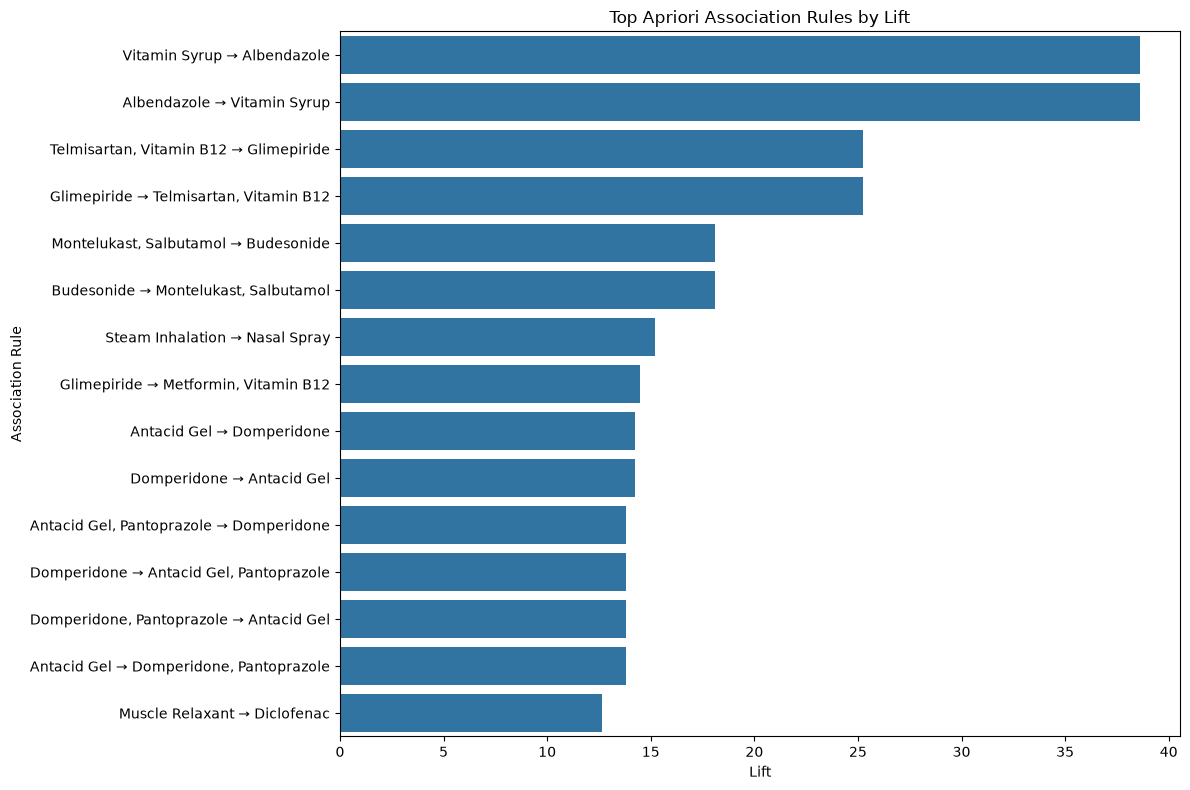

In [55]:
# select the fifteen highest-lift rules for focused visualization.
top_apriori_rules = readable_rules.head(15).copy()

# create a descriptive rule label combining antecedent and consequent medicines.
top_apriori_rules['Rule'] = top_apriori_rules['antecedents'] + ' → ' + top_apriori_rules['consequents']

# set the figure size for comparing rule strength.
plt.figure(figsize=(12, 8))

# compare the selected association rules by lift value.
sns.barplot(data=top_apriori_rules, x='lift', y='Rule')

# add a title to the strongest Apriori-rule visualization.
plt.title("Top Apriori Association Rules by Lift")

# label the horizontal axis.
plt.xlabel("Lift")

# label the vertical axis.
plt.ylabel("Association Rule")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


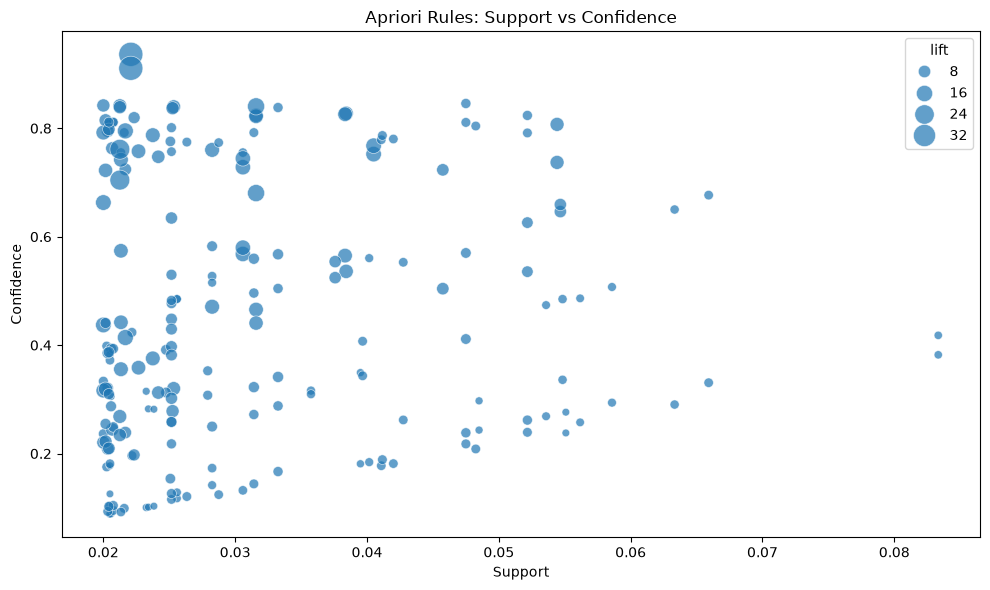

In [56]:
# set the figure size for examining rule-quality relationships.
plt.figure(figsize=(10, 6))

# plot support against confidence while representing lift through bubble size.
sns.scatterplot(data=rules, x='support', y='confidence', size='lift', sizes=(30, 300), alpha=0.7)

# add a title to the rule-quality scatter plot.
plt.title("Apriori Rules: Support vs Confidence")

# label the horizontal axis.
plt.xlabel("Support")

# label the vertical axis.
plt.ylabel("Confidence")

# adjust spacing
plt.tight_layout()

# show the plot
plt.show()


## Observation:
The strongest rules show frequently occurring medicine combinations with high confidence and lift. For example, Vitamin Syrup → Albendazole has about 93.6% confidence and 38.6 lift, showing a strong association in the dataset.

# 17. Interpreting the Results

For each strong rule, students should answer:

1. **What does the rule say?**
2. **How common is the combination?** → Support
3. **How reliable is the directional relationship?** → Confidence
4. **Is the relationship stronger than random co-occurrence?** → Lift
5. **What pharmacy or operational decision could the pattern support?**
6. **Could diagnosis, department, season, or patient profile explain the rule?**
7. **Does the rule require clinical validation before any healthcare use?** → Always yes

### Example Business Uses

Strong co-prescription patterns may support:

- Coordinated stock replenishment
- Detection of medicines with linked demand
- Department-specific stock allocation
- Seasonal pharmacy inventory planning
- Identification of prescription patterns for further clinical review

# 18. What to Include in the Conclusion

The conclusion should go beyond simply saying that Apriori generated association rules.

A stronger conclusion should discuss:

- Which medicines appeared most frequently
- Which departments and diagnoses generated the highest prescription activity
- Whether prescription demand showed seasonal patterns
- How the raw dataset was converted into transaction baskets
- How the minimum-support threshold affected frequent itemsets
- Which rules had the strongest confidence and lift
- How those rules could support pharmacy inventory decisions
- Why association does not imply clinical causation
- Limitations of Apriori on large transaction datasets

## Next Stage

After completing this notebook, the same basket can be analyzed using **FP-Growth** and the results can be compared with Apriori for:

- Execution speed
- Frequent itemsets
- Number of rules
- Rule quality
- Scalability